# Impact métier du modèle de prévision

Ce carnet mesure ce que le modèle **fait gagner à l'exploitant**, et non sa précision statistique. La
précision est traitée dans `model_selection.ipynb` ; ici on cherche autre chose : si les prévisions
avaient piloté une boucle de recommandation, qu'est-ce que cela aurait changé.

**Ce que ce carnet mesure.** Deux indicateurs métier, calculés sur la période de test, avec et sans
recommandation, et la comparaison qui isole l'apport du modèle.

**Ce qu'il ne mesure pas.** Aucune charge n'a réellement été déplacée. L'effet d'une recommandation
suivie est une **hypothèse paramétrée**, explicitée à la section 4 et balayée à la section 6. Les
chiffres qui suivent mesurent donc le couple modèle plus hypothèse, jamais le modèle seul. C'est
assumé : le critère d'épreuve demande des KPI sur des processus métier **simulés**.

**Périmètre.** Les sept sites du parc, sur l'historique complet partagé par l'équipe : deux bureaux,
deux usines, un datacenter, un commerce et un hôpital.

**Lien avec les tickets.** La boucle de recommandation n'existe pas encore : #43, #44 et #45 sont
ouverts, et la règle appartient à l'applicatif, pas au service ML (`docs/api.md`, section 6). La
règle appliquée ici est donc une **simulation de la règle à venir**, écrite à partir des paramètres
déjà tranchés : seuil de vigilance à 80 % de la capacité souscrite par défaut (`docs/data.md`),
horizon de 1 à 48 heures (`docs/api.md`). Ce carnet ne crée aucun module : il fige par la mesure le
seuil de déclenchement que #44 devra implémenter.

## 1. Données, modèle et bornes de l'étude

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

from data import read_training_history
from features import MINIMUM_HISTORY_HOURS, load_site_schedules
from models import PredictionService, PredictionTarget, load_model
from training import VALIDATION_QUANTILE


def repository_root():
    """Remonte jusqu'au dossier qui porte `.git`, pour ne dépendre ni du répertoire de travail
    du noyau ni de la profondeur du carnet dans l'arborescence."""
    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Racine du dépôt introuvable depuis " + str(Path.cwd()))


REPOSITORY_ROOT = repository_root()

# Mêmes variables d'environnement que le service, mêmes défauts. Le carnet suit donc un
# PARQUET_DIR déplacé sans qu'on ait à l'éditer.
PARQUET_DIRECTORY = Path(os.getenv("PARQUET_DIR") or REPOSITORY_ROOT / "data" / "parquet")
SITES_FILE = PARQUET_DIRECTORY / "sites.parquet"
MODEL_FILE = Path(
    os.getenv("ML_MODEL_PATH") or REPOSITORY_ROOT / "apps" / "ml" / "artifacts" / "catboost_model.cbm"
)
SCHEDULES_FILE = Path(
    os.getenv("ML_SITE_CONFIG_PATH") or REPOSITORY_ROOT / "apps" / "ml" / "config" / "sites.json"
)

# Paramètres de la simulation. Chacun est justifié dans la section qui l'utilise.
FORECAST_HORIZON_HOURS = 24      # horizon par défaut du contrat d'API
ORIGIN_STEP_HOURS = 6            # un exploitant ne relit pas sa prévision toutes les heures
DEFAULT_THRESHOLD_RATIO = 0.80   # seuil de vigilance par défaut, docs/data.md
SHIFT_WINDOW_HOURS = 3           # report autorisé de plus ou moins trois heures
DEFERRABLE_SHARE = 0.15          # part de charge déplaçable, hypothèse de référence
ACCEPTANCE_RATE = 1.00           # part des recommandations suivies, hypothèse de référence
RANDOM_SEED = 42

# Les grilles du balayage de la section 6. L'hypothèse de référence appartient aux deux.
DEFERRABLE_GRID = [0.05, 0.10, DEFERRABLE_SHARE, 0.20, 0.30]
ACCEPTANCE_GRID = [0.25, 0.50, 0.75, ACCEPTANCE_RATE]

# Identifiants des trois bras, écrits une fois : ils servent de clés et d'étiquettes.
ARM_NONE = "A rien"
ARM_REACTIVE = "B seuil"
ARM_FORECAST = "C prevision"

In [2]:
history = read_training_history(PARQUET_DIRECTORY)
sites = pq.read_table(SITES_FILE).to_pandas().set_index("id")
schedules = load_site_schedules(SCHEDULES_FILE)
model = load_model(MODEL_FILE)

# Le modèle a été entraîné sur les heures les plus anciennes de cette fenêtre. La coupe vient de
# `training`, et non d'un second littéral : une valeur recopiée dériverait sans rien casser, et
# l'étude se mettrait à mesurer le modèle sur des heures qu'il a déjà vues.
TRAINING_CUTOFF = history["timestamp"].quantile(VALIDATION_QUANTILE)
test_block = history[history["timestamp"] > TRAINING_CUTOFF]

print(f"historique lu         : {len(history):,} lignes, {history.site_id.nunique()} sites")
print(f"fin de l'entrainement : {TRAINING_CUTOFF}")
print(f"bloc de test          : {test_block.timestamp.min()} -> {test_block.timestamp.max()}")
print(f"                        {len(test_block):,} heures")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

historique lu         : 122,647 lignes, 7 sites
fin de l'entrainement : 2026-05-31 23:00:00
bloc de test          : 2026-06-01 00:00:00 -> 2026-09-18 11:00:00
                        18,396 heures


In [3]:
# Le seuil de vigilance par défaut, celui que l'applicatif applique tant qu'aucun réglage manuel
# n'est saisi. warning_threshold_kw vit en base et n'est pas dans le Parquet : la simulation ne
# connaît donc que le défaut, et c'est une limite à garder en tête.
SITE_IDS = sorted(history.site_id.unique())
thresholds = {
    site_id: DEFAULT_THRESHOLD_RATIO * float(sites.loc[site_id, "capacity_kw"])
    for site_id in SITE_IDS
}

summary = []
for site_id, block in test_block.groupby("site_id"):
    above = int((block.consumption_kwh_corrected > thresholds[site_id]).sum())
    summary.append({
        "site": site_id,
        "type": sites.loc[site_id, "type"],
        "capacite_kw": sites.loc[site_id, "capacity_kw"],
        "seuil_kw": thresholds[site_id],
        "moyenne_kwh": block.consumption_kwh_corrected.mean(),
        "heures_au_dessus": above,
        "part_%": 100 * above / len(block),
    })
pd.DataFrame(summary).round(1)

,site,type,capacite_kw,seuil_kw,moyenne_kwh,heures_au_dessus,part_%
0,SITE001,office,200.0,160.0,91.6,282,10.7
1,SITE002,factory,1000.0,800.0,538.7,827,31.5
2,SITE003,datacenter,800.0,640.0,717.3,2559,97.4
3,SITE004,retail,400.0,320.0,224.2,307,11.7
4,SITE005,hospital,600.0,480.0,461.6,647,24.6
5,SITE006,office,180.0,144.0,80.3,141,5.4
6,SITE007,factory,950.0,760.0,501.7,787,29.9


Première lecture, et elle pèse sur toute la suite : **les sites à charge plate passent la
quasi-totalité de leurs heures au-dessus de leur seuil de vigilance par défaut**, leur charge de base
approchant leur capacité souscrite. Une règle calée sur ce défaut y déclencherait en permanence, ce
qui n'est pas une alerte mais un bruit de fond. On garde le défaut pour la mesure de référence, et la
section 7 documente l'ajustement.

## 2. Rejouer la prévision sur le bloc de test

Toutes les six heures, on demande au modèle les vingt-quatre heures suivantes, en ne lui donnant que
l'historique réellement connu à cet instant. La prévision est autorégressive : chaque heure prédite
devient le décalage de la suivante, exactement comme en production.

In [4]:
def backtest(site_id, horizon=FORECAST_HORIZON_HOURS, step=ORIGIN_STEP_HOURS):
    """Rejoue la prévision toutes les `step` heures sur le bloc de test d'un site."""
    # `read_training_history` rend déjà les lignes triées par site puis par horodatage.
    site_history = history[history.site_id == site_id]
    first_origin = site_history[site_history.timestamp > TRAINING_CUTOFF].timestamp.min()
    last_origin = site_history.timestamp.max() - pd.Timedelta(hours=horizon)
    origins = pd.date_range(start=first_origin, end=last_origin, freq=f"{step}h")

    rows = []
    for origin in origins:
        known = site_history[site_history.timestamp <= origin].tail(MINIMUM_HISTORY_HOURS)
        service = PredictionService(model, known, schedules)
        targets = [
            PredictionTarget(site_id, (origin + pd.Timedelta(hours=k)).to_pydatetime())
            for k in range(1, horizon + 1)
        ]
        for prediction in service.predict(targets):
            due_at = pd.Timestamp(prediction.timestamp)
            rows.append({
                "site_id": site_id,
                "origin": origin,
                "due_at": due_at,
                "lead_hours": int((due_at - origin).total_seconds() // 3600),
                "forecast_kwh": prediction.consumption_kwh,
            })
    return pd.DataFrame(rows)


forecasts = pd.concat([backtest(site_id) for site_id in SITE_IDS], ignore_index=True)

observed = history[["site_id", "timestamp", "consumption_kwh_corrected"]].rename(
    columns={"timestamp": "due_at", "consumption_kwh_corrected": "observed_kwh"}
)
forecasts = forecasts.merge(observed, on=["site_id", "due_at"], how="left")
forecasts["absolute_error"] = (forecasts.forecast_kwh - forecasts.observed_kwh).abs()

print(f"{len(forecasts):,} previsions, {forecasts.origin.nunique():,} origines")
forecasts.head()

72,912 previsions, 434 origines


,site_id,origin,due_at,lead_hours,forecast_kwh,observed_kwh,absolute_error
0,SITE001,2026-06-01,2026-06-01 01:00:00,1,59.259826,61.23,1.970174
1,SITE001,2026-06-01,2026-06-01 02:00:00,2,60.127582,59.97,0.157582
2,SITE001,2026-06-01,2026-06-01 03:00:00,3,61.447781,65.98,4.532219
3,SITE001,2026-06-01,2026-06-01 04:00:00,4,59.922608,59.90,0.022608
4,SITE001,2026-06-01,2026-06-01 05:00:00,5,61.144394,59.10,2.044394


### Dégradation par horizon

Résultat intermédiaire, absent du carnet de sélection : celui-ci mesurait l'erreur sur une fenêtre
unique de 168 heures. Ici on dispose de centaines de fenêtres, donc de l'erreur **en fonction de la
distance à l'origine**. C'est la grandeur qui décide si une recommandation à vingt-quatre heures a un
sens.

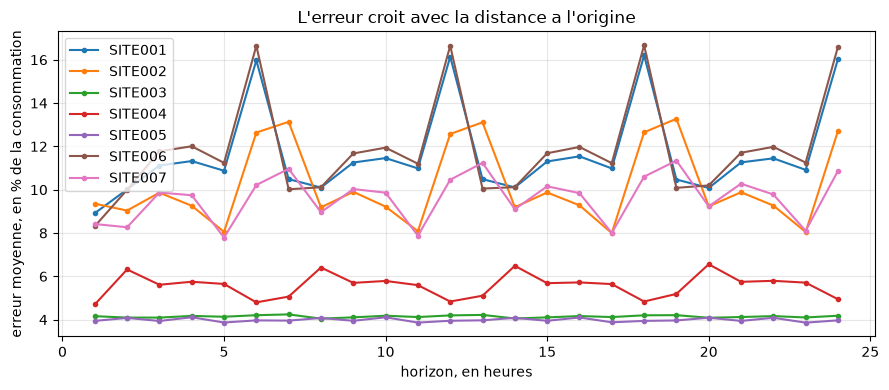

site_id,SITE001,SITE002,SITE003,SITE004,SITE005,SITE006,SITE007
lead_hours,,,,,,,
1,8.9,9.4,4.2,4.7,3.9,8.3,8.4
6,16.0,12.6,4.2,4.8,4.0,16.6,10.2
12,16.1,12.6,4.2,4.8,3.9,16.6,10.5
24,16.0,12.7,4.2,4.9,4.0,16.6,10.9


In [5]:
by_horizon = (
    forecasts.groupby(["site_id", "lead_hours"])
    .agg(mae=("absolute_error", "mean"), observed_mean=("observed_kwh", "mean"))
    .reset_index()
)
by_horizon["mae_relative_%"] = 100 * by_horizon.mae / by_horizon.observed_mean

_, axes = plt.subplots(figsize=(9, 4))
for site_id, group in by_horizon.groupby("site_id"):
    axes.plot(group.lead_hours, group["mae_relative_%"], marker="o", markersize=3, label=site_id)
axes.set_xlabel("horizon, en heures")
axes.set_ylabel("erreur moyenne, en % de la consommation")
axes.set_title("L'erreur croit avec la distance a l'origine")
axes.legend()
axes.grid(alpha=0.3)
plt.tight_layout()
plt.show()

horizon_marks = [1, FORECAST_HORIZON_HOURS // 4, FORECAST_HORIZON_HOURS // 2, FORECAST_HORIZON_HOURS]
by_horizon[by_horizon.lead_hours.isin(horizon_marks)].pivot(
    index="lead_hours", columns="site_id", values="mae_relative_%"
).round(1)

## 3. La règle de recommandation, et les trois bras de comparaison

Le ticket demande de comparer « avec et sans recommandation ». Pris au pied de la lettre, cela mesure
la boucle de recommandation, pas le modèle. On ajoute donc un troisième bras.

| Bras | Ce qu'il représente | Ce qu'il peut faire |
| :--- | :--- | :--- |
| A, rien | la série réelle | rien, c'est la référence |
| B, seuil réactif (#43) | on agit quand la mesure dépasse | seulement sur les heures **suivantes** |
| C, anticipation (#44) | on agit sur une prévision | sur l'heure visée elle-même |

`C - A` mesure l'intérêt de la boucle. **`C - B` mesure l'apport du modèle**, et c'est le seul écart
qui répond à la question posée.

In [6]:
def recommendations_from_forecast(site_forecasts, threshold):
    """Une recommandation par heure future dont la prevision franchit le seuil.

    Une meme heure peut etre signalee par plusieurs origines : on garde le preavis le plus long,
    celui qui laisse le plus de marge de manoeuvre a l'exploitant.
    """
    flagged = site_forecasts[site_forecasts.forecast_kwh > threshold]
    return (
        flagged.sort_values("lead_hours", ascending=False)
        .drop_duplicates("due_at")
        .sort_values("due_at")[["due_at", "lead_hours"]]
        .reset_index(drop=True)
    )


def recommendations_from_measurements(series, threshold):
    """Le reactif ne voit le depassement qu'une fois consomme : il ne vise que l'heure d'apres."""
    due = series.index[series > threshold] + pd.Timedelta(hours=1)
    return pd.DataFrame({"due_at": due[due.isin(series.index)], "lead_hours": 1})

## 4. Le modèle d'effet

C'est l'hypothèse centrale, et elle est explicite. Quand une recommandation est suivie pour l'heure
`h` :

- une part `DEFERRABLE_SHARE` de la charge de `h` est **déplaçable**, le reste ne l'est pas ;
- elle part vers les heures de la fenêtre de plus ou moins trois heures, dans la **même journée** ;
- chaque heure d'accueil ne reçoit que ce qui lui manque pour atteindre le seuil, jamais plus : on ne
  crée pas un pic en en effaçant un autre ;
- **l'énergie totale est conservée**. Un décalage ne fait pas disparaître de kWh, et c'est pour cela
  que le KPI porte sur l'énergie *au-dessus du seuil* et non sur la consommation.

`ACCEPTANCE_RATE` dit quelle part des recommandations est effectivement suivie. Le tirage est
déterministe par `RANDOM_SEED`, pour que le carnet soit rejouable.

In [7]:
def apply_shift(series, due_times, threshold, deferrable=DEFERRABLE_SHARE,
                acceptance=ACCEPTANCE_RATE, window=SHIFT_WINDOW_HOURS, seed=RANDOM_SEED):
    """Applique le modele d'effet et rend la serie contrefactuelle et l'energie deplacee."""
    shifted = series.copy()
    moved_total = 0.0
    due_times = list(due_times)
    generator = np.random.default_rng(seed)
    followed = generator.random(len(due_times)) < acceptance

    for due_at, is_followed in zip(due_times, followed):
        if not is_followed or due_at not in shifted.index:
            continue
        movable = deferrable * shifted[due_at]
        if movable <= 0:
            continue

        # Les heures d'accueil : la fenetre autour de l'heure visee, sans deborder de la journee,
        # et chacune ne peut recevoir que ce qui lui manque pour atteindre le seuil.
        neighbours = [
            due_at + pd.Timedelta(hours=offset)
            for offset in range(-window, window + 1)
            if offset != 0
        ]
        room = {
            timestamp: max(0.0, threshold - shifted[timestamp])
            for timestamp in neighbours
            if timestamp in shifted.index and timestamp.date() == due_at.date()
        }
        available = sum(room.values())
        if available <= 0:
            continue

        moved = min(movable, available)
        shifted[due_at] -= moved
        for timestamp, capacity in room.items():
            shifted[timestamp] += moved * capacity / available
        moved_total += moved

    return shifted, moved_total

## 5. Les deux KPI

**KPI 1, pics anticipés.** Part des dépassements réels annoncés au moins une heure à l'avance,
accompagnée du taux de fausses alertes. Le second est obligatoire : sans lui, le premier se maximise
en criant au loup en permanence.

**KPI 2, énergie de dépassement évitée.** Somme des kWh consommés au-dessus du seuil, comparée entre
les bras. On publie à côté l'**énergie déplacée**, qui est le coût opérationnel de la manoeuvre, et
leur rapport : combien de kWh de dépassement on évite par kWh déplacé. Un rapport inférieur à 1 veut
dire qu'on dérange beaucoup pour gagner peu.

In [8]:
def overrun_energy(series, threshold):
    """Les kWh consommes au-dessus du seuil : ce que la manoeuvre cherche a effacer."""
    return float((series - threshold).clip(lower=0).sum())


def anticipated_peaks(recommendations, series, threshold):
    """Rappel des depassements annonces, taux de fausses alertes et preavis median."""
    real_peaks = set(series.index[series > threshold])
    announced = set(recommendations.due_at)
    return {
        "peaks": len(real_peaks),
        "recall_%": 100 * len(real_peaks & announced) / len(real_peaks) if real_peaks else np.nan,
        "false_alarm_%": 100 * len(announced - real_peaks) / len(announced) if announced else np.nan,
        "median_lead_h": recommendations.lead_hours.median() if announced else np.nan,
    }

In [9]:
def site_context(site_id, threshold):
    """La serie observee et les deux jeux de recommandations.

    Rien ici ne depend de l'hypothese de report : le balayage de la section 6 le calcule donc une
    seule fois par site, au lieu d'une fois par combinaison.
    """
    site_forecasts = forecasts[forecasts.site_id == site_id]
    series = (
        history[(history.site_id == site_id) & (history.timestamp.isin(site_forecasts.due_at))]
        .set_index("timestamp")
        .consumption_kwh_corrected.sort_index()
    )
    return series, {
        ARM_REACTIVE: recommendations_from_measurements(series, threshold),
        ARM_FORECAST: recommendations_from_forecast(site_forecasts, threshold),
    }


def evaluate_arms(site_id, threshold, context, deferrable=DEFERRABLE_SHARE,
                  acceptance=ACCEPTANCE_RATE, arms=(ARM_REACTIVE, ARM_FORECAST)):
    """Le KPI 2 sur le bras de reference et sur les bras demandes."""
    series, recommendations = context
    baseline_overrun = overrun_energy(series, threshold)
    rows = [{
        "site": site_id,
        "bras": ARM_NONE,
        "recommandations": 0,
        "depassement_kwh": baseline_overrun,
        "evite_kwh": 0.0,
        "deplace_kwh": 0.0,
        "efficacite": np.nan,
    }]

    for arm in arms:
        shifted, moved = apply_shift(
            series, recommendations[arm].due_at, threshold, deferrable, acceptance
        )
        overrun = overrun_energy(shifted, threshold)
        rows.append({
            "site": site_id,
            "bras": arm,
            "recommandations": len(recommendations[arm]),
            "depassement_kwh": overrun,
            "evite_kwh": baseline_overrun - overrun,
            "deplace_kwh": moved,
            "efficacite": (baseline_overrun - overrun) / moved if moved > 0 else np.nan,
        })

    return pd.DataFrame(rows)


def evaluate_all(threshold_by_site, deferrable=DEFERRABLE_SHARE, acceptance=ACCEPTANCE_RATE):
    """Les deux KPI sur tous les sites, pour un jeu de seuils donne."""
    arm_rows, peak_rows = [], []
    for site_id in SITE_IDS:
        threshold = threshold_by_site[site_id]
        series, recommendations = site_context(site_id, threshold)
        arm_rows.append(
            evaluate_arms(site_id, threshold, (series, recommendations), deferrable, acceptance)
        )
        peak_rows.append({
            "site": site_id,
            **anticipated_peaks(recommendations[ARM_FORECAST], series, threshold),
        })
    return pd.concat(arm_rows, ignore_index=True), pd.DataFrame(peak_rows)


arms_table, peaks_table = evaluate_all(thresholds)

In [10]:
print("KPI 1 : pics anticipes, bras C")
display(peaks_table.round(1))

print()
print("KPI 2 : energie de depassement, par bras")
display(arms_table.round(1))

KPI 1 : pics anticipes, bras C


,site,peaks,recall_%,false_alarm_%,median_lead_h
0,SITE001,281,63.7,40.7,22.0
1,SITE002,823,93.2,17.9,21.0
2,SITE003,2553,100.0,2.6,21.0
3,SITE004,306,69.6,44.8,21.0
4,SITE005,641,46.2,46.7,21.0
5,SITE006,139,17.3,40.0,22.0
6,SITE007,783,88.3,17.2,21.0



KPI 2 : energie de depassement, par bras


,site,bras,recommandations,depassement_kwh,evite_kwh,deplace_kwh,efficacite
0,SITE001,A rien,0,2153.9,0.0,0.0,NaN
1,SITE001,B seuil,281,933.2,1220.7,6563.0,0.2
2,SITE001,C prevision,302,732.0,1421.9,7195.5,0.2
3,SITE002,A rien,0,56894.8,0.0,0.0,NaN
4,SITE002,B seuil,823,31898.2,24996.6,63491.4,0.4
5,SITE002,C prevision,934,24569.6,32325.3,79312.0,0.4
6,SITE003,A rien,0,203285.2,0.0,0.0,NaN
7,SITE003,B seuil,2552,202419.6,865.7,953.9,0.9
8,SITE003,C prevision,2622,202419.6,865.7,978.8,0.9
9,SITE004,A rien,0,4254.7,0.0,0.0,NaN


In [11]:
# L'ecart qui repond a la question : ce que le modele apporte face au seuil reactif.
pivot = arms_table.pivot(index="site", columns="bras", values="evite_kwh")
pivot["apport du modele (C - B)"] = pivot[ARM_FORECAST] - pivot[ARM_REACTIVE]
pivot.round(1)

bras,A rien,B seuil,C prevision,apport du modele (C - B)
site,,,,
SITE001,0.0,1220.7,1421.9,201.2
SITE002,0.0,24996.6,32325.3,7328.7
SITE003,0.0,865.7,865.7,0.0
SITE004,0.0,2302.3,3233.9,931.6
SITE005,0.0,3534.6,3789.7,255.2
SITE006,0.0,261.3,134.1,-127.2
SITE007,0.0,21835.0,28917.9,7082.9


## 6. Sensibilité à l'hypothèse

Les deux paramètres de la section 4 ne sont pas mesurés, ils sont posés. On ne publie donc pas un
chiffre mais une surface, et surtout le point où le gain s'annule.

In [12]:
sweep_rows = []
for site_id in SITE_IDS:
    threshold = thresholds[site_id]
    context = site_context(site_id, threshold)   # constant sur tout le balayage de ce site
    for deferrable in DEFERRABLE_GRID:
        for acceptance in ACCEPTANCE_GRID:
            arms = evaluate_arms(
                site_id, threshold, context, deferrable, acceptance, arms=(ARM_FORECAST,)
            )
            forecast_arm = arms[arms.bras == ARM_FORECAST].iloc[0]
            sweep_rows.append({
                "part_deplacable": deferrable,
                "taux_acceptation": acceptance,
                "evite_kwh": forecast_arm.evite_kwh,
                "deplace_kwh": forecast_arm.deplace_kwh,
            })

sweep_table = (
    pd.DataFrame(sweep_rows)
    .groupby(["part_deplacable", "taux_acceptation"], as_index=False)[["evite_kwh", "deplace_kwh"]]
    .sum()
)
sweep_table["efficacite"] = sweep_table.evite_kwh / sweep_table.deplace_kwh

print("Energie de depassement evitee, en kWh, tous sites")
sweep_table.pivot(index="part_deplacable", columns="taux_acceptation", values="evite_kwh").round(0)

Energie de depassement evitee, en kWh, tous sites


taux_acceptation,0.25,0.50,0.75,1.00
part_deplacable,,,,
0.05,9852.0,19480.0,29596.0,38245.0
0.10,14665.0,29510.0,46052.0,59452.0
0.15,16932.0,34496.0,54867.0,70688.0
0.20,17788.0,37182.0,60046.0,77691.0
0.30,18241.0,40515.0,67472.0,88206.0


In [13]:
print("Efficacite : kWh de depassement evites par kWh deplace")
sweep_table.pivot(index="part_deplacable", columns="taux_acceptation", values="efficacite").round(2)

Efficacite : kWh de depassement evites par kWh deplace


taux_acceptation,0.25,0.50,0.75,1.00
part_deplacable,,,,
0.05,0.59,0.59,0.59,0.58
0.10,0.47,0.46,0.46,0.45
0.15,0.38,0.36,0.36,0.35
0.20,0.31,0.29,0.29,0.28
0.30,0.23,0.22,0.22,0.21


## 7. L'ajustement documenté : le seuil du datacenter

La section 1 l'a montré : le défaut à 80 % de la capacité souscrite est inopérant sur un site dont la
charge de base vaut environ 90 % de cette capacité.

**Ce qui est changé.** Le déclencheur est remplacé, **pour les seuls sites qui saturent**, par un
percentile de leur propre historique d'entraînement.

**Pourquoi.** Le seuil cesse alors de décrire un contrat d'abonnement pour décrire le comportement
observé du site. Une alerte permanente n'est pas une alerte, et la mesure ci-dessous le chiffre.

**Ce que cela coûte.** Le seuil ajusté ne parle plus de la capacité souscrite, donc il ne dit plus
rien du risque de pénalité. Les deux lectures sont complémentaires, pas interchangeables.

In [14]:
SATURATION_LIMIT_PERCENT = 50.0   # au-dela, le seuil decrit le regime normal du site
ADJUSTED_PERCENTILE = 0.90        # le site est signale sur ses propres heures hautes

training_block = history[history.timestamp <= TRAINING_CUTOFF]
adjusted = {}
adjustment_rows = []
for site_id, block in training_block.groupby("site_id"):
    consumption = block.consumption_kwh_corrected
    saturation = 100 * (consumption > thresholds[site_id]).mean()
    is_saturated = saturation > SATURATION_LIMIT_PERCENT
    adjusted[site_id] = (
        float(consumption.quantile(ADJUSTED_PERCENTILE)) if is_saturated else thresholds[site_id]
    )
    adjustment_rows.append({
        "site": site_id,
        "saturation_entrainement_%": saturation,
        "seuil_defaut_kw": thresholds[site_id],
        "seuil_ajuste_kw": adjusted[site_id],
        "ajuste": is_saturated,
    })

pd.DataFrame(adjustment_rows).round(1)

,site,saturation_entrainement_%,seuil_defaut_kw,seuil_ajuste_kw,ajuste
0,SITE001,14.9,160.0,160.0,False
1,SITE002,34.6,800.0,800.0,False
2,SITE003,98.0,640.0,779.9,True
3,SITE004,17.0,320.0,320.0,False
4,SITE005,35.7,480.0,480.0,False
5,SITE006,9.6,144.0,144.0,False
6,SITE007,33.6,760.0,760.0,False


In [15]:
adjusted_arms_table, adjusted_peaks_table = evaluate_all(adjusted)

comparison = peaks_table.set_index("site")[["peaks", "recall_%", "false_alarm_%"]].join(
    adjusted_peaks_table.set_index("site")[["peaks", "recall_%", "false_alarm_%"]],
    lsuffix="_avant",
    rsuffix="_apres",
)
comparison.round(1)

,peaks_avant,recall_%_avant,false_alarm_%_avant,peaks_apres,recall_%_apres,false_alarm_%_apres
site,,,,,,
SITE001,281,63.7,40.7,281,63.7,40.7
SITE002,823,93.2,17.9,823,93.2,17.9
SITE003,2553,100.0,2.6,176,0.0,NaN
SITE004,306,69.6,44.8,306,69.6,44.8
SITE005,641,46.2,46.7,641,46.2,46.7
SITE006,139,17.3,40.0,139,17.3,40.0
SITE007,783,88.3,17.2,783,88.3,17.2


## 8. Synthèse

Les conclusions de ce carnet sont reprises dans `docs/ml.md`, avec les écarts, **y compris ceux qui
sont défavorables au modèle**. Ce carnet en est la pièce justificative : il se rejoue d'une commande
et ses chiffres sont reproductibles à graine fixée.

In [16]:
print("Bloc de test :", test_block.timestamp.min(), "->", test_block.timestamp.max())
print("Sites        :", ", ".join(SITE_IDS))
print("Hypothese    : part deplacable", DEFERRABLE_SHARE, "| acceptation", ACCEPTANCE_RATE)
print()
print("Seuil par defaut, tous sites :")
print(arms_table.groupby("bras")[["evite_kwh", "deplace_kwh"]].sum().round(1).to_string())
print()
print("Seuil ajuste, tous sites :")
print(adjusted_arms_table.groupby("bras")[["evite_kwh", "deplace_kwh"]].sum().round(1).to_string())

Bloc de test : 2026-06-01 00:00:00 -> 2026-09-18 11:00:00
Sites        : SITE001, SITE002, SITE003, SITE004, SITE005, SITE006, SITE007
Hypothese    : part deplacable 0.15 | acceptation 1.0

Seuil par defaut, tous sites :
             evite_kwh  deplace_kwh
bras                               
A rien             0.0          0.0
B seuil        55016.0     180664.8
C prevision    70688.5     200937.6

Seuil ajuste, tous sites :
             evite_kwh  deplace_kwh
bras                               
A rien             0.0          0.0
B seuil        54842.1     198947.6
C prevision    69822.8     199958.8
